# Single-amplitude toy MCMC

This notebook is a stripped-down sibling of `mcmc.py`: it keeps the same
importance-weighted pipeline scaffolding (catalog load, effective PSD,
Gaussian likelihood, NUTS, saving, diagnostics) but replaces the
cosmology/population callback with a trivial one-parameter model. The SGWB
spectral density $S_h(f, \Lambda)$ scales linearly with a single scalar
`amplitude` ($A$) through the total merger rate; the importance weights are
all unity (relative ESS = 1), so this exercises the same
`merger_rate_and_log_weights_fn` interface without any real astrophysics.

It is a smoke/sanity test: can NUTS recover a known injected amplitude from
a fiducial catalog?

To run the notebook end-to-end you must point `CATALOG_PATH` at an `.npz`
polarization-power catalog (schema documented below).

## Imports and JAX configuration

In [55]:
from datetime import datetime
from functools import partial
import json
import multiprocessing
from pathlib import Path

# Setting JAX to use all available CPU cores for parallelization
num_cpus = multiprocessing.cpu_count()
import numpyro

numpyro.set_host_device_count(num_cpus)

import arviz_base as azb
import arviz_plots as azp
import arviz_stats as azs
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS

from astrogwb.sampling.numpyro_model import numpyro_model
from astrogwb.gwb import (
    spectral_density,
    spectral_snr_squared,
    frequency_mask as make_frequency_mask,
)
from astrogwb.detector import load_sensitivity_map, effective_psd
from astrogwb.waveform import load_polarization_power_catalog
from astrogwb.utils import years_to_seconds

# gwpy (via gwmock-signal) replaces matplotlib's default rectilinear axes; ArviZ 1.2
# mis-detects gwpy axes and looks for arviz_plots.backend.gwpy. Restore matplotlib axes.
from matplotlib.axes import Axes as MplAxes
from matplotlib.projections import register_projection

register_projection(MplAxes)

plt.style.library["paper-figures"] = {
    # "figure.figsize": (colwidth, colwidth),
    "figure.dpi": 200,
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.size": 14,
    "axes.labelsize": "medium",
    "axes.titlesize": "medium",
    "figure.labelsize": "medium",
    "figure.titlesize": "medium",
    # Make the legend/label fonts a little smaller
    "legend.fontsize": "small",
    "legend.title_fontsize": "small",
    "xtick.labelsize": "small",
    "ytick.labelsize": "small",
}

jax.config.update("jax_enable_x64", True)
%config InlineBackend.figure_format = 'retina'
azp.style.use("arviz-variat")

## Pipeline configuration

In [56]:
DEBUG = False  # small smoke settings for first runs; set False for the production run

def get_root_dir() -> Path:
    return Path.cwd().parent


ROOT_DIR = get_root_dir()
CATALOG_PATH = ROOT_DIR / "out/bns_waveforms_df=1Hz.npz"

# Detector settings
detnames = ("S1", "R1")  # resolve via bundled geometry.toml / sensitivity.toml
observation_time = 1.0  # [yr]; cancels in S_h, kept for the likelihood scale

# MCMC settings
seed = 42
num_chains = num_cpus  # one chain per CPU core
num_warmup = 200
num_samples = 500
target_accept = 0.9

if DEBUG:
    num_warmup, num_samples, num_chains, target_accept = 100, 100, 1, 0.9

# Frequency band for the analysis
f_min = 2
f_max = 4096

# The toy model: S_h is linear in `amplitude` through the merger rate; the
# importance weights are all unity, so `merger_rate_norm` sets the SNR scale.
merger_rate_norm = 1e-3  # mergers/sec, hand-picked, tunable for SNR
amplitude_fiducial = 1.0

fiducials = {"amplitude": amplitude_fiducial}
hyperprior_dists = {"amplitude": dist.Uniform(0.1, 10.0)}

sampled_params = set(("amplitude",))

priors = {k: hyperprior_dists[k] for k in sampled_params}
constants = {k: v for k, v in fiducials.items() if k not in sampled_params}

## Loading the waveform catalog

Our method requires a waveform catalog computed for a fiducial population of CBCs. We offer a script to generate that in the [scripts directory](../scripts/generate_polarization_power_catalog.py).

The catalog is an `.npz` file with this schema:

- `frequencies` — shape `(nfreq,)`, the FFT frequency grid (Hz).
- `polarization_power` — shape `(nfreq, nsamples)`, the raw per-source
  $|\tilde{h}_+(f)|^2 + |\tilde{h}_\times(f)|^2$
- `samples` — per-source parameters, stored as `sample__<name>` keys and restored into a dict.

In [57]:
catalog = load_polarization_power_catalog(CATALOG_PATH)

frequencies = jnp.asarray(catalog.frequencies)
polarization_power = jnp.asarray(catalog.polarization_power)  # (nfreq, nsamples)
samples = {name: jnp.asarray(v) for name, v in catalog.samples.items()}

n_freq, n_samples = polarization_power.shape
print(f"loaded catalog: n_frequency_bins={n_freq} n_proposal_samples={n_samples}")

loaded catalog: n_frequency_bins=4097 n_proposal_samples=16384


## Effective PSD and analysis band

`load_sensitivity_map` resolves the str-named detectors (e.g. `S1`, `R1`, `C1`) via the bundled
`geometry.toml` / `sensitivity.toml`. We then calculate the effective power spectral density

$$
S_{\mathrm{eff}} = \left(\sum_{a,b} \frac{\Gamma^2_{ab}(f)}{S_{n,a} S_{n,b}}  \right)^{-1/2}
$$

In [58]:
sensitivities = load_sensitivity_map(detnames)
effective_psd_arr = jnp.asarray(
    effective_psd(frequencies, list(detnames), sensitivities)
)
mask = make_frequency_mask(frequencies, fmin=f_min, fmax=f_max)
print("band bins:", int(jnp.sum(mask)), "of", frequencies.shape[0])

band bins: 4095 of 4097


## The single-amplitude toy model

The predicted spectral density is

$$
S_h(f, A) = \frac{N(A)}{T}\frac{1}{N_{\mathrm{inj}}} \sum_{i=1}^{N_{\mathrm{inj}}} \left [ |\tilde{h}_+(f, \theta_i)|^2 + |\tilde{h}_\times (f, \theta_i)|^2 \right ],
$$

i.e. it scales **linearly** in $A$ through the total merger rate
$N(A)/T = A \times \texttt{merger\_rate\_norm}$. The importance weights are
all unity (the catalog samples are drawn from the fiducial population and
never reweighted), so the relative ESS stays at 1 throughout the run — this
notebook is only exercising the amplitude scaling of the callback interface.

In [59]:
def merger_rate_and_log_weights_fn(params, samples):
    total_merger_rate = params["amplitude"] * merger_rate_norm
    log_weights = jnp.zeros(n_samples)
    return total_merger_rate, log_weights


weights_fid = jnp.ones((n_samples,))
rate_fid = amplitude_fiducial * merger_rate_norm
observed_spectral_density = spectral_density(
    polarization_power, weights_fid, rate_fid, average_mode="analytic_inclination"
)

## Running the MCMC

We run the NUTS sampler as implemented in the `numpyro` python package.

In [60]:
model = partial(
    numpyro_model,
    observation_time=observation_time,
    average_mode="analytic_inclination",
    merger_rate_and_log_weights_fn=merger_rate_and_log_weights_fn,
    priors=priors,
    constants=constants,
    frequency_mask=mask,
)

kernel = NUTS(
    model,
    target_accept_prob=target_accept,
    forward_mode_differentiation=True,
    dense_mass=True,
)
mcmc = MCMC(
    kernel,
    num_warmup=num_warmup,
    num_samples=num_samples,
    num_chains=num_chains,
    progress_bar=True,
    jit_model_args=True,
    chain_method="vectorized",
)
rng_key = jax.random.PRNGKey(seed)
mcmc.run(
    rng_key,
    frequencies=frequencies,
    polarization_power=polarization_power,
    samples=samples,
    observed_spectral_density=observed_spectral_density,
    effective_psd=effective_psd_arr,
    extra_fields=("num_steps", "accept_prob", "diverging"),
)
mcmc.print_summary()

sample: 100%|██████████| 700/700 [00:19<00:00, 36.10it/s]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
  amplitude      1.00      0.18      1.00      0.70      1.30   1481.07      1.01

Number of divergences: 0


## Saving the run

We convert to an `xarray.DataTree` via `arviz_base` and write it to NetCDF,
alongside a small JSON record of the run configuration.

In [61]:


out_dir = Path("chains")
out_dir.mkdir(exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
params_suffix = "-".join(sampled_params)
det_suffix = ",".join(detnames)
base = f"chains-amplitude-toy-{params_suffix}-det={det_suffix}-seed{seed}-{timestamp}"

inference_data = azb.from_numpyro(mcmc)
inference_data.to_netcdf(out_dir / f"{base}.nc")

run_config = {
    "catalog_path": str(CATALOG_PATH),
    "detectors": list(detnames),
    "seed": seed,
    "observation_time": observation_time,
    "sampled_params": list(sampled_params),
    "fiducials": fiducials,
    "merger_rate_norm": merger_rate_norm,
    "sampler": {
        "num_warmup": num_warmup,
        "num_samples": num_samples,
        "num_chains": num_chains,
        "target_accept": target_accept,
    },
}
(out_dir / f"{base}.json").write_text(json.dumps(run_config, indent=2))
print("saved:", base)

saved: chains-amplitude-toy-amplitude-det=S1,R1-seed42-20260707-113412


## Diagnostic plots

In [62]:
summary = azs.summary(inference_data, var_names=list(sampled_params))
summary

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
amplitude,0.999,0.184,0.71,1.3,1496,1301,1.01,0.0047,0.0033


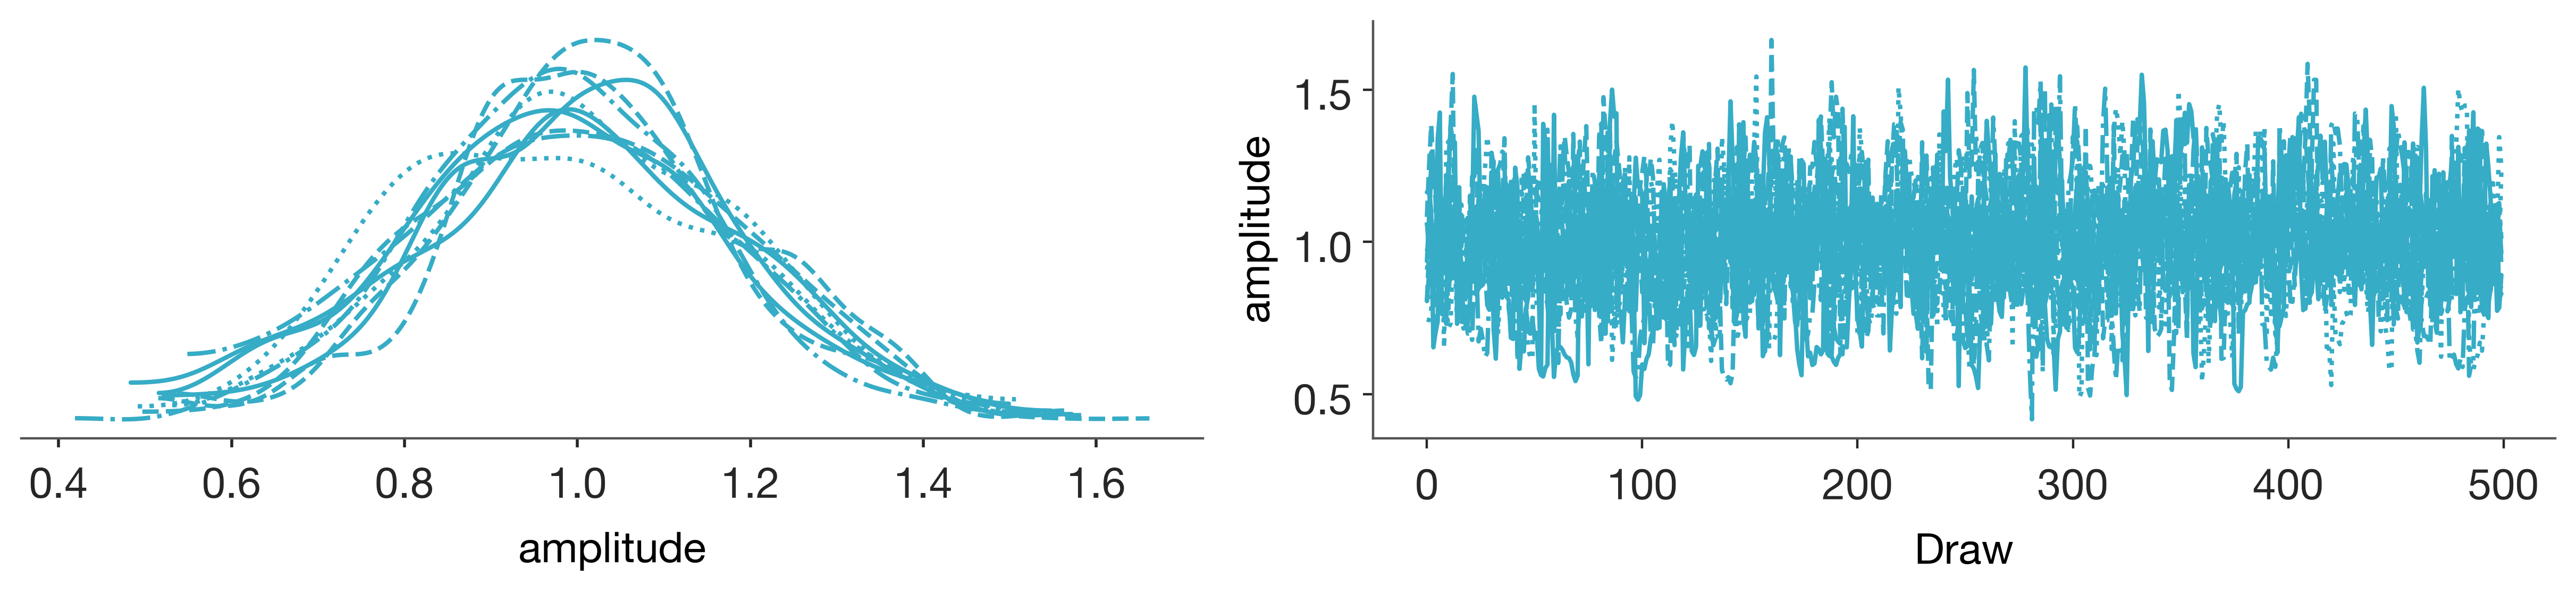

In [63]:
azp.plot_trace_dist(inference_data, var_names=list(sampled_params))

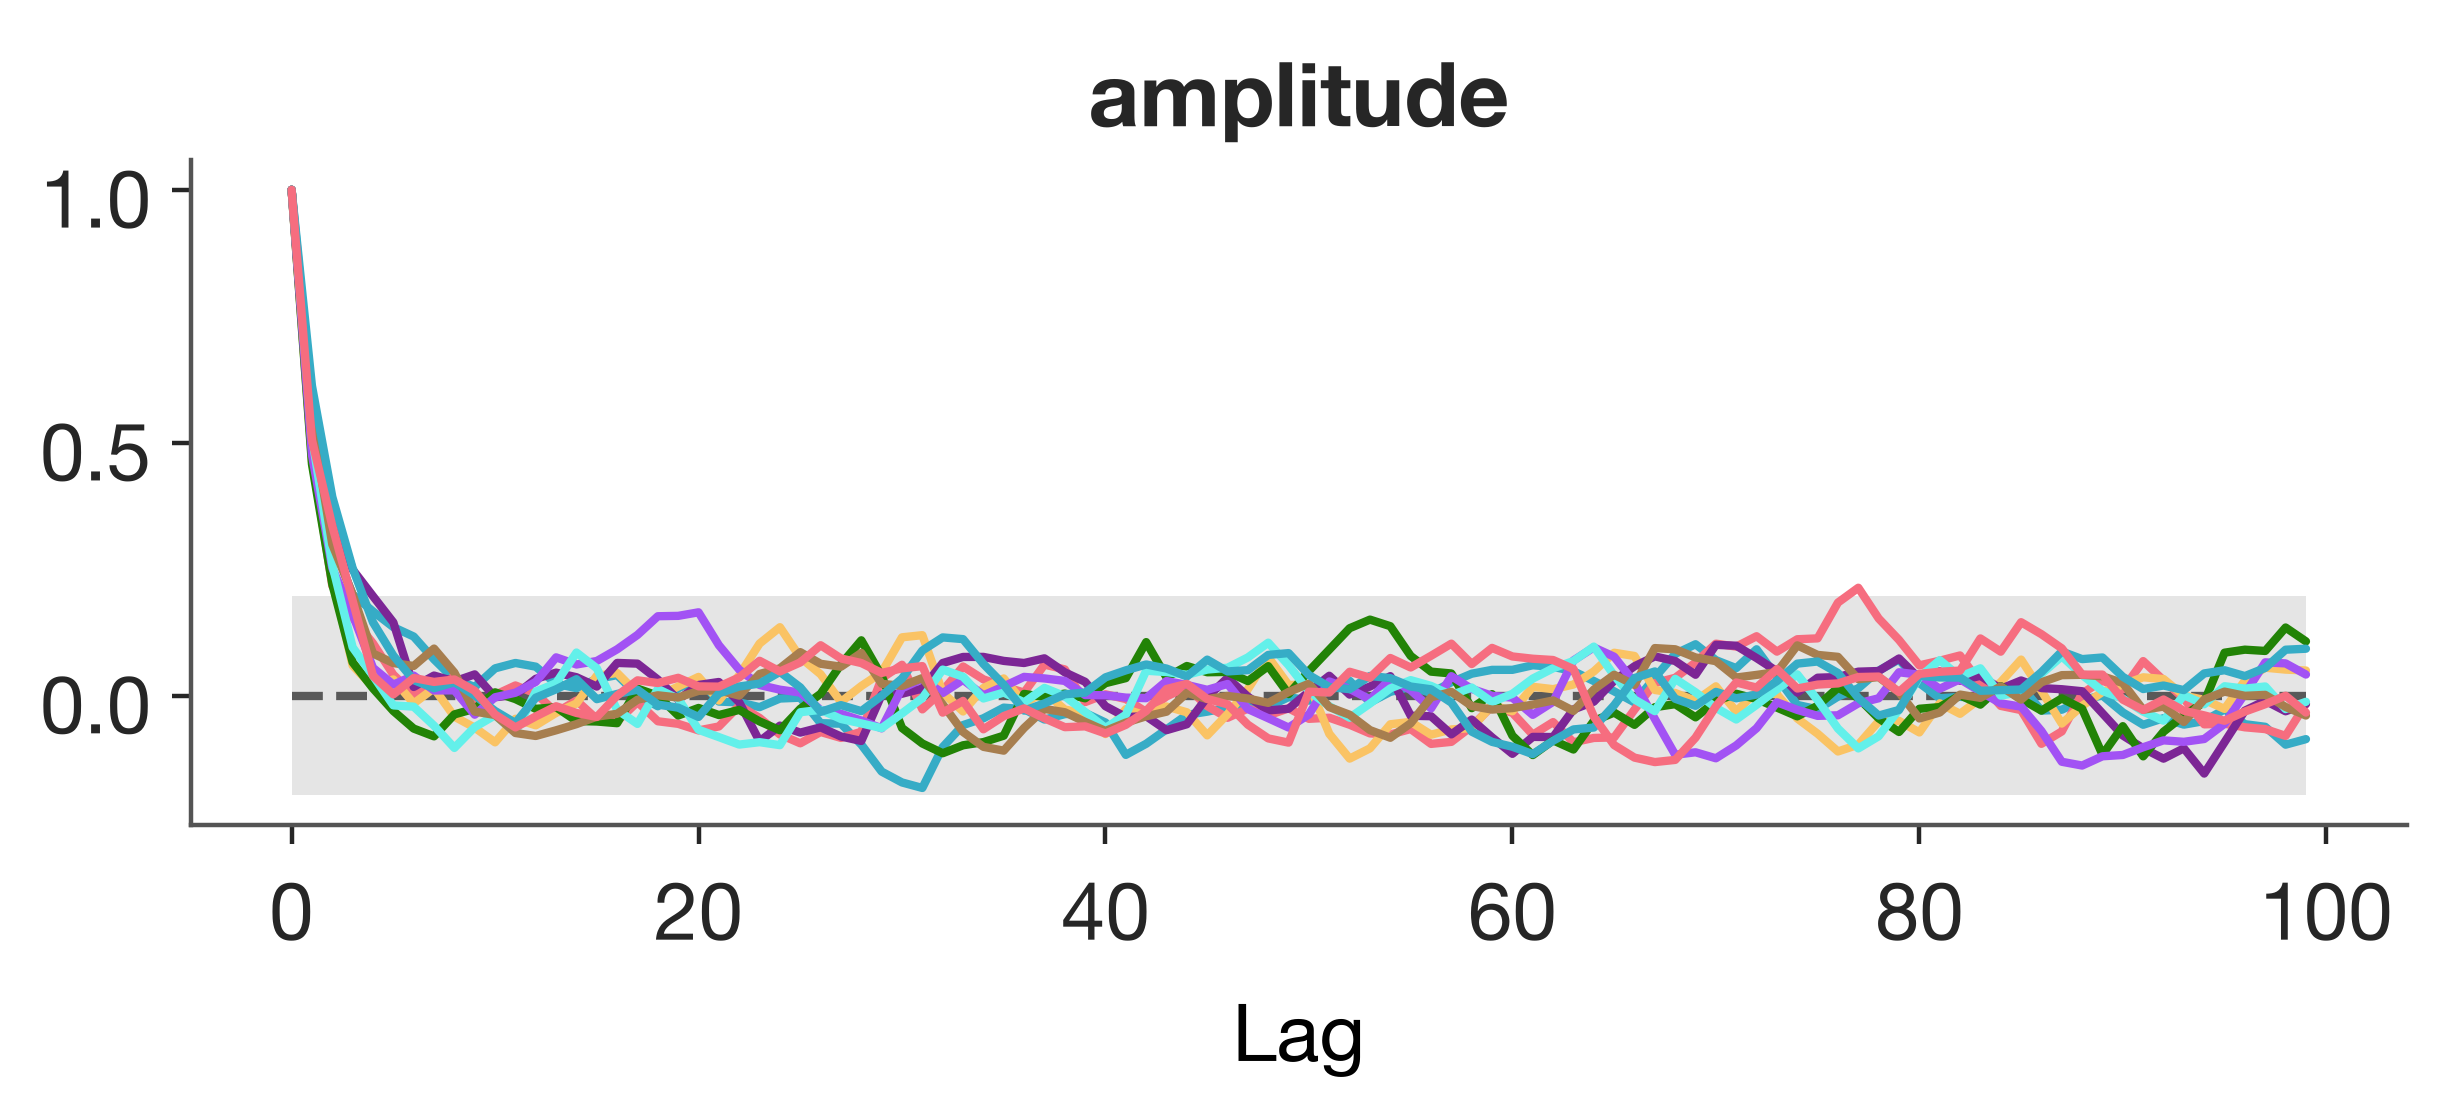

In [64]:
azp.plot_autocorr(inference_data, var_names=list(sampled_params))

## Posterior vs. the Fisher–Gaussian (Laplace) approximation

For the linear model $S_h(f, A) = A \, s(f)$ with a per-bin Gaussian likelihood
of scale `gaussian_bin_scale` $= S_{\mathrm{eff}} / \sqrt{2 T \Delta f}$, the
Fisher information at the fiducial amplitude is

$$
I(A_{\mathrm{fid}}) = \sum_i \left(\frac{\partial S_h}{\partial A}\right)^2 \Big/ \sigma_i^2
= \frac{\mathrm{SNR}^2}{A_{\mathrm{fid}}^2},
$$

since $\partial S_h/\partial A = s = S_h^{\mathrm{obs}}/A_{\mathrm{fid}}$ and
$\mathrm{SNR}^2$ is exactly `spectral_snr_squared` of the fiducial (observed)
spectral density. The Laplace/Cramér–Rao posterior width is therefore
$\sigma_A \approx A_{\mathrm{fid}} / \mathrm{SNR}$. We overlay
$\mathcal{N}(A_{\mathrm{fid}}, \sigma_A^2)$ on the sampled marginal as a
sanity check.

In [65]:
df = float(jnp.mean(jnp.diff(frequencies)))
T_sec = float(years_to_seconds(observation_time))
snr_sq = spectral_snr_squared(
    observed_spectral_density[mask], effective_psd_arr[mask], T_sec, df
)
snr = float(jnp.sqrt(snr_sq))
sigma_fisher = float(amplitude_fiducial / snr)
print(f"SNR={snr:.3f} sigma_fisher={sigma_fisher:.3f}")

SNR=5.570 sigma_fisher=0.180


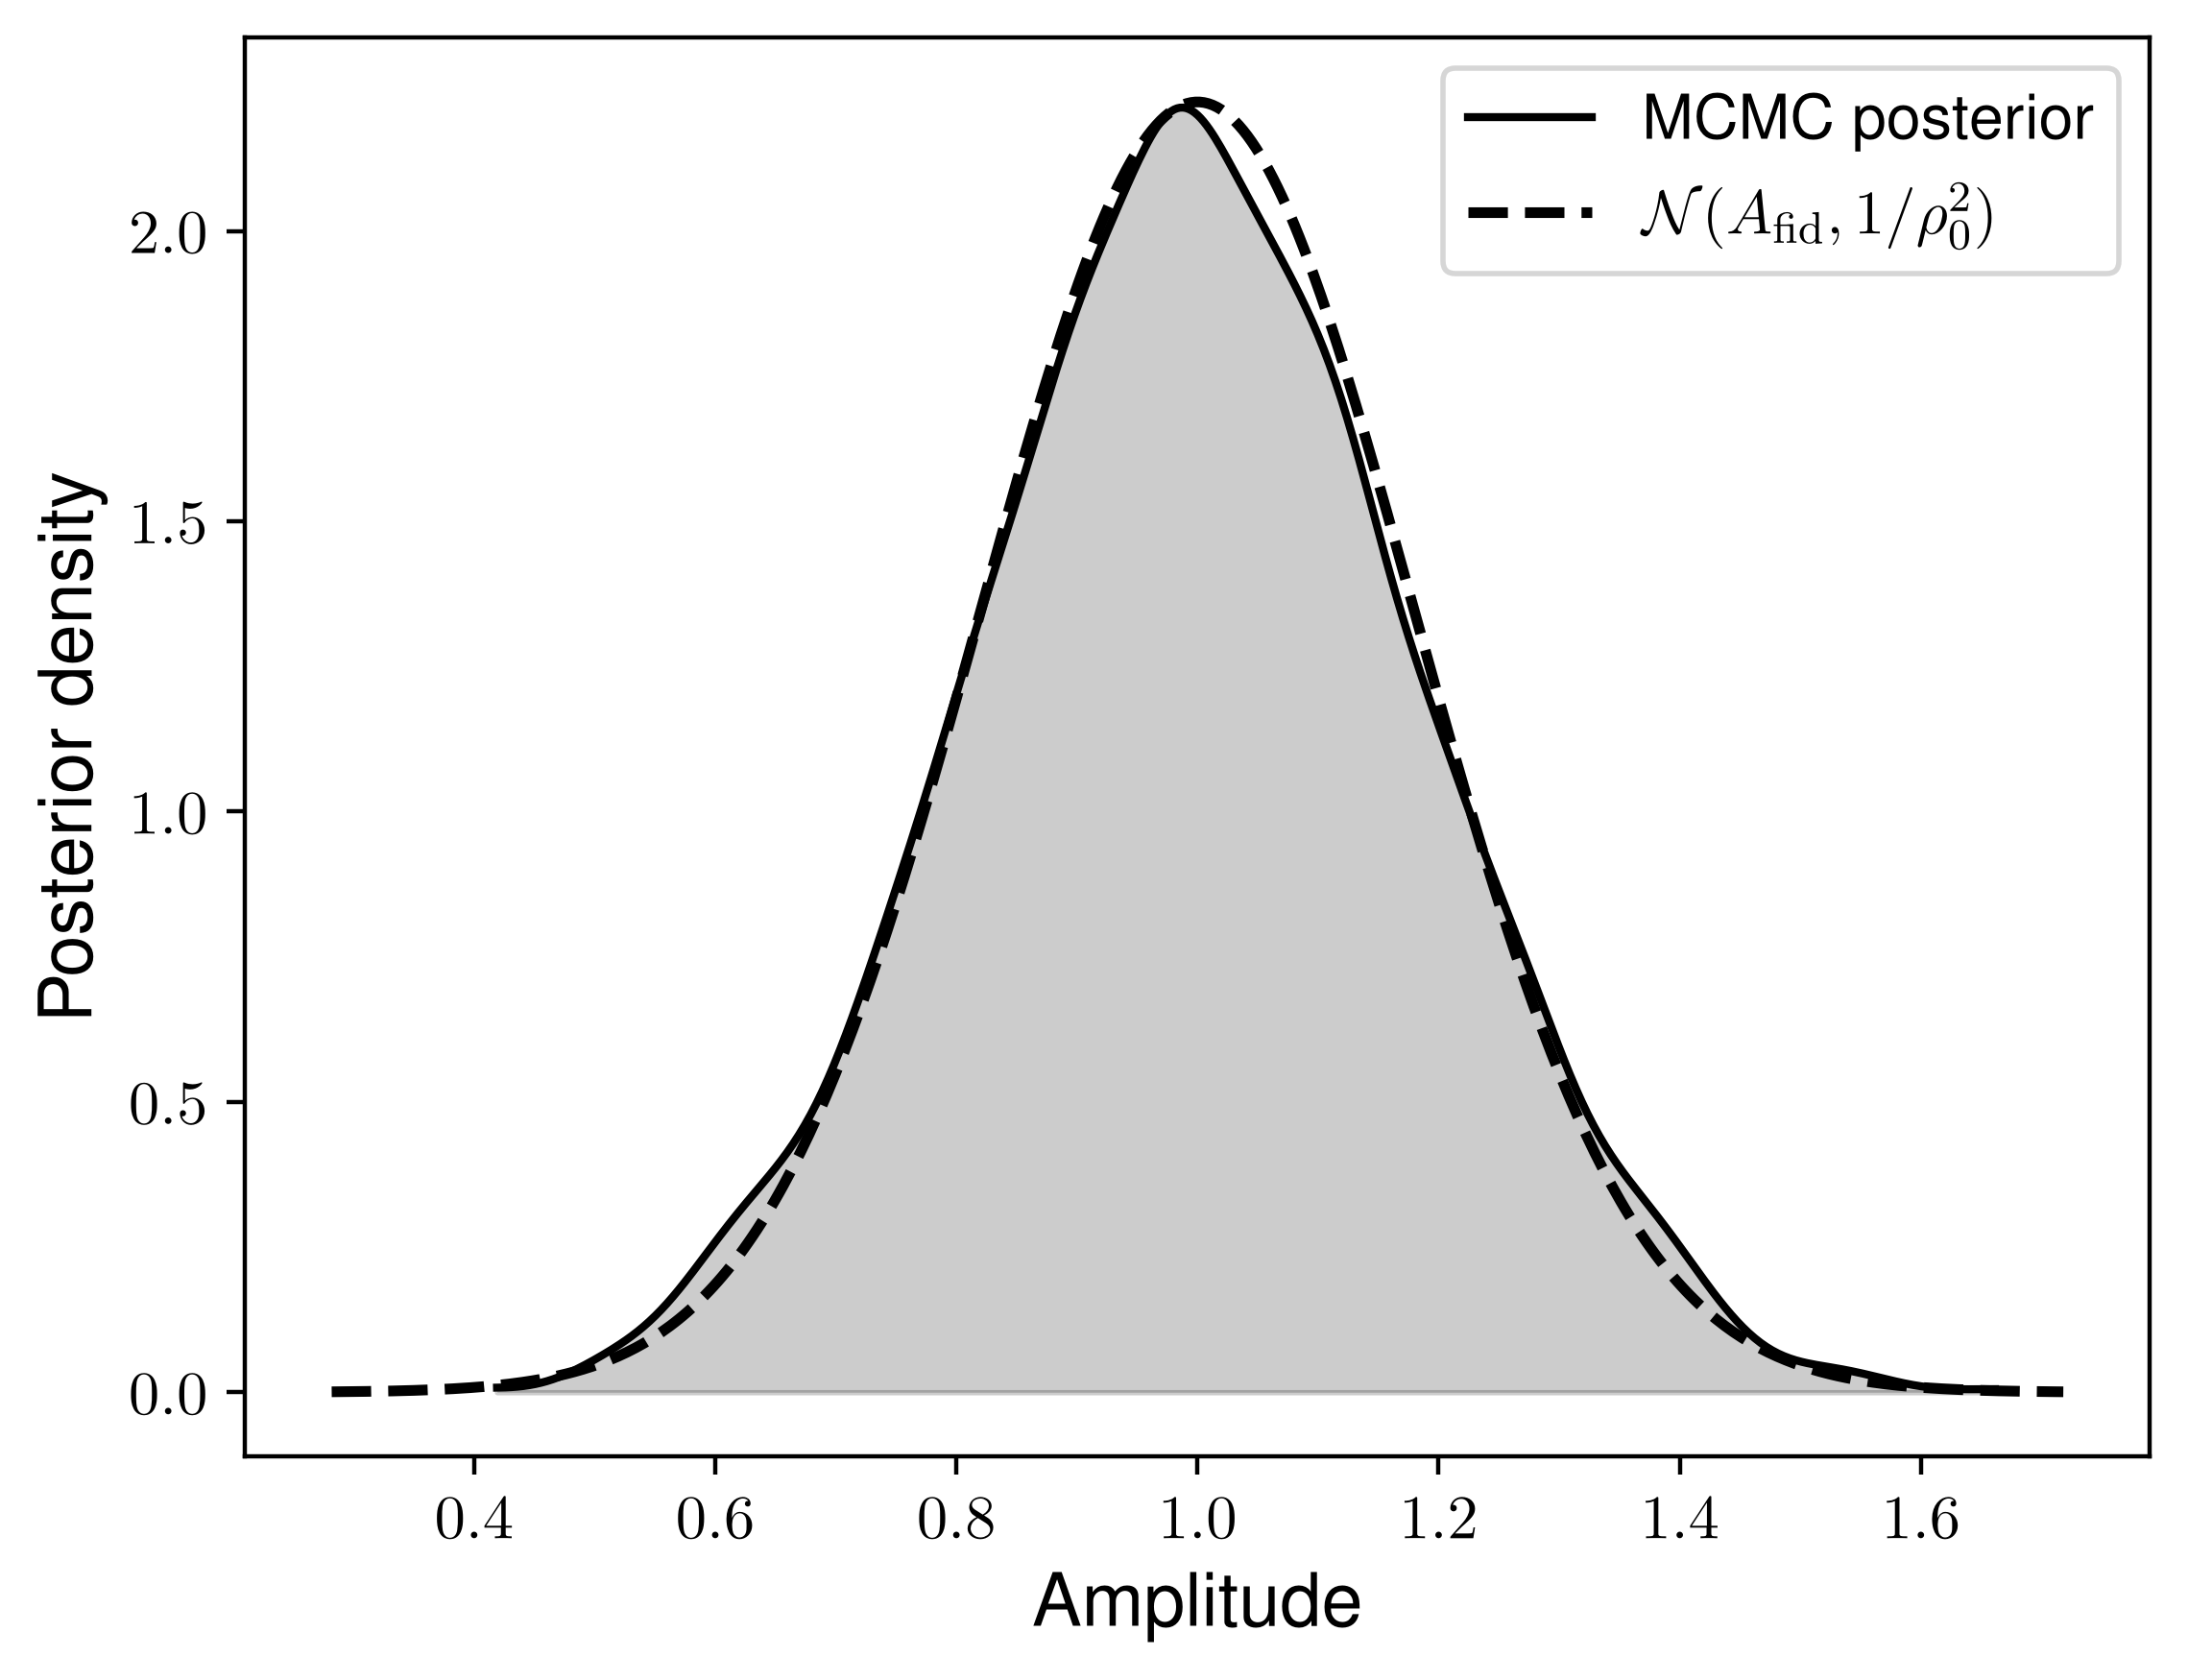

In [66]:
kde = azs.kde(inference_data, var_names=["amplitude"])["amplitude"]
x_kde = kde.sel(plot_axis="x").values
y_kde = kde.sel(plot_axis="y").values

mu = amplitude_fiducial
x = np.linspace(mu - 4 * sigma_fisher, mu + 4 * sigma_fisher, 400)
pdf = np.exp(-0.5 * ((x - mu) / sigma_fisher) ** 2) / (
    sigma_fisher * np.sqrt(2 * np.pi)
)

# Scoped reset: `azp.style.use` above mutated the global matplotlib rcParams,
# which would otherwise leak arviz's styling into this hand-built figure too.
with plt.style.context("paper-figures", after_reset=True):
    fig, ax = plt.subplots()
    ax.plot(x_kde, y_kde, label="MCMC posterior", color="black")
    ax.fill_between(x_kde, y_kde, alpha=0.2, color="black")
    ax.plot(
        x,
        pdf,
        linestyle="--",
        label=r"$\mathcal{N}(A_\mathrm{fid}, 1/\rho_0^2)$",
        color="black",
        lw=2.0,
    )
    ax.set_xlabel("Amplitude")
    ax.set_ylabel("Posterior density")
    ax.legend(loc="upper right")